In [1]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
from scipy.io import loadmat
import random
import pickle
import sys
from sklearn.linear_model import RidgeCV
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec

In [2]:
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_neu.pkl', "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']


N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_23664\3800015342.py:2: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_neu.pkl', "rb") as input_file:
C:\Users\katie\AppData\Local\Temp\ipykernel_23664\3800015342.py:12: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


[22 20  4 12  2  6 15 16  8 19 10  5 17 13 26  1  9 11  7  3 24 21]
>>> best_lam returning: 11.937766417144381


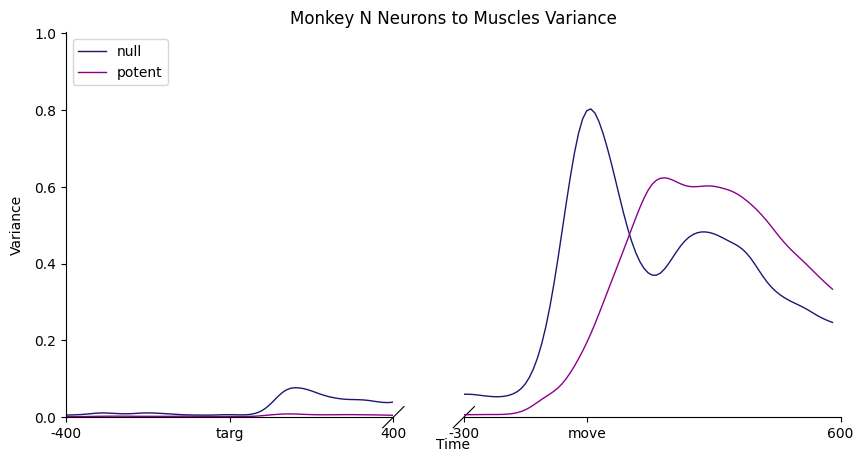

In [3]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor)

[21 17 26 10 23 11  0  5 12  9 13 16 19 25  2 15 18 20  4 24  8  7]
>>> best_lam returning: 34.55107294592218


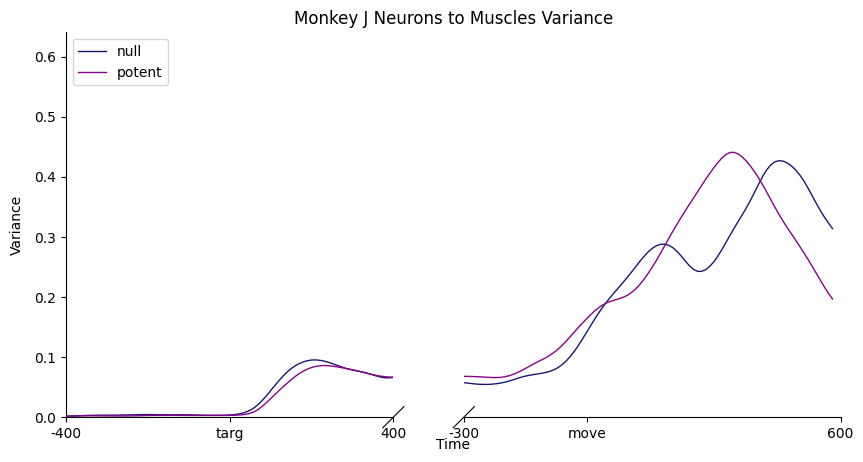

In [4]:
pcar.sup_tuning(J_ntm_tensor, J_mus_tensor)

# best lam = 100

[ 7  6 26 11  0  4  1 25 14 17 20 16 22 10  2 24  8  5 19  3  9 23]
>>> best_lam returning: 20.30917620904739


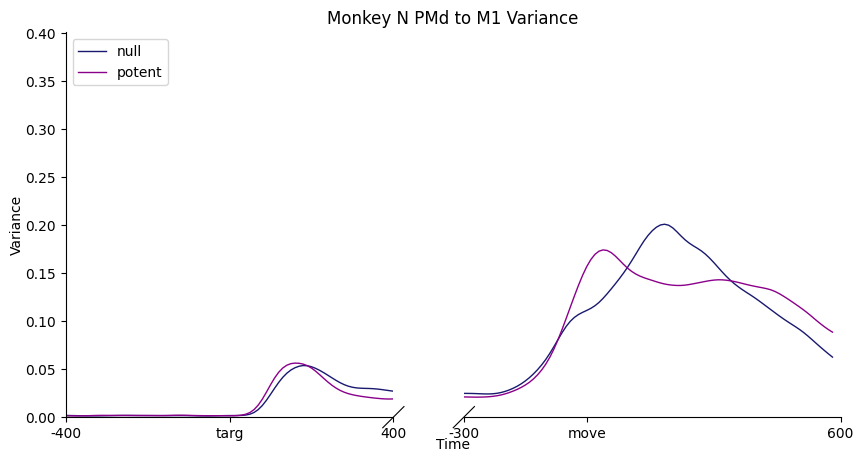

In [5]:
pcar.sup_tuning(N_PMd_tensor, N_M1_tensor, dims = 14) 

# best lam = 58.780160722749116

[ 13   6  27   8  45  98  66  99  37  68  38  26  47  31  46  12  69 103
  81  65  14  25  34  95  96   3   2  18   7  22 100  32  55  64  94  59
 104   4  89  11  84  85  60  91  82   5 102  44   1   0  63  19  35  56
  23  79  77  52  70  10  97  57  58  29  42  74 107  39  53  78  62  83
 101  87  54  73  48  49  33  50  28  40  80  75  15  41  86]
>>> best_lam returning: 11.937766417144381


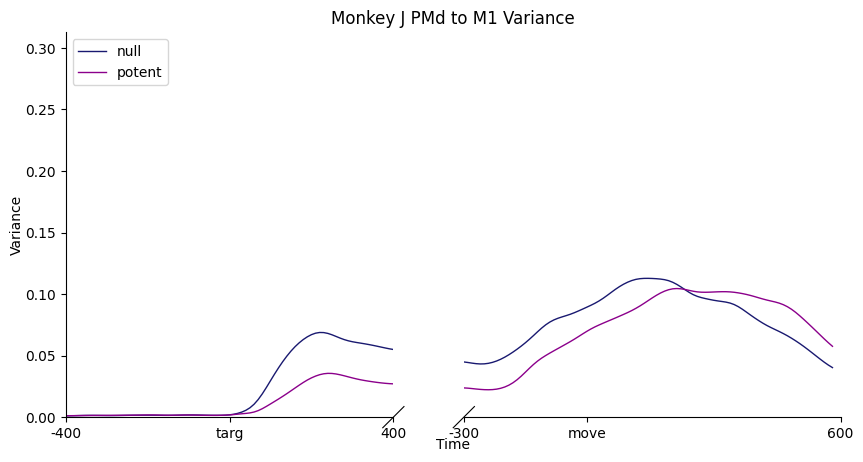

In [6]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[ 19  43  34  97  18  70   8  51  85 103  79  12  62  50  55  94  10  66
  16  46  96  37   6  40  27  69   2   4  35  29 101  25  72  42  11  67
   1  89  23  84  63  13  74 106  99  98  21  52  39  53 105   7  22  44
  65  30  56  14  32  83  57  92 102  95  80  24   5  64  68  36 104  76
  41  58  82  87  90   0  75  91  31  28  48  54  73 100  38]
>>> best_lam returning: 11.937766417144381


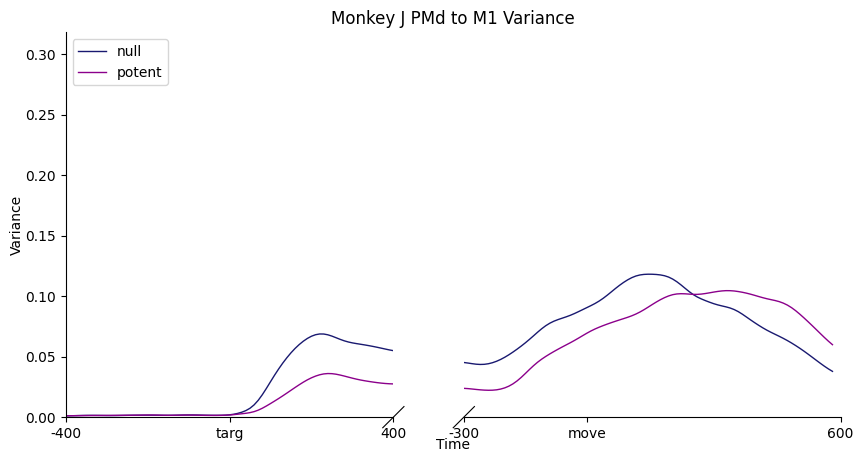

In [7]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[ 9 19 15 12  7 23 17  8 26 16 14  6 11 20  0  1 22  5 24 25 13 18]
>>> best_lam returning: 20.30917620904739


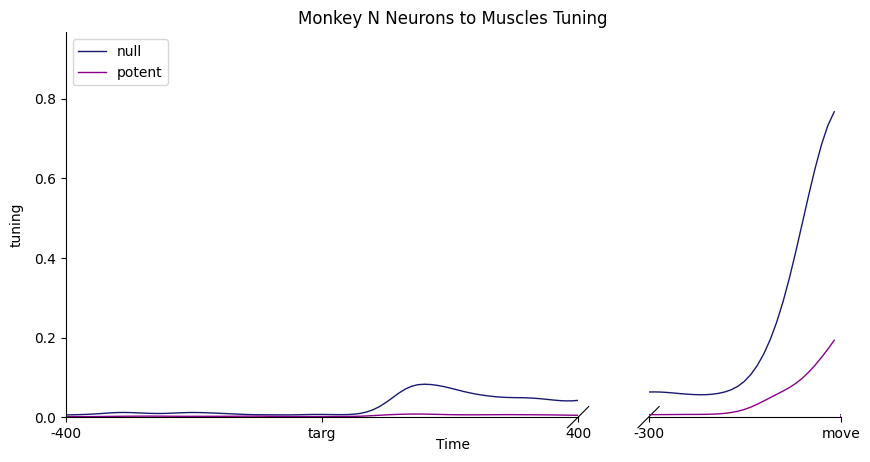

In [8]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor, fig_4D = True)

In [9]:
def fig4_d (tensor_N, tensor_M, dims):

    
    # retrieving dataset specifications 
    J, PMd = pcar.ident(tensor_N)

    # getting weights matrix for potent and null space 
    cond, _, fin_time = tensor_N.shape
    regress_N, _, _ = pcar.time_shift(tensor_N, tensor_M, fig4 = True)
    N_tilde, _, _ = pcar.run_PCA(regress_N, dims)
    W_potent, W_null = pcar.tuning_setup(tensor_N, tensor_M, dims, time = True)
    
    # projecting the neural activity of 400ms before and after target and 300ms before and 800ms after move starts onto the potent and null space of the weights matrix
    N_potent = N_tilde @ W_potent
    N_null = N_tilde @ W_null

    # reshaping into a tensor 
    pot_tensor = pcar.shape_tensor(N_potent, cond)
    null_tensor = pcar.shape_tensor(N_null, cond)
    _, _, time = pot_tensor.shape

    # initializing array for holding the variance 
    V_pot = np.zeros(time)
    V_null = np.zeros(time)
    _, _, time = null_tensor.shape

    ratio = np.zeros(time)

    for t in range(time):

        Xn = null_tensor[:,:,t]
        Xp = pot_tensor[:,:,t]

        # subtract condition mean
        Xn -= Xn.mean(axis=0, keepdims=True)
        Xp -= Xp.mean(axis=0, keepdims=True)

        V_null = np.sum(Xn**2)
        V_pot  = np.sum(Xp**2)

        ratio[t] = (1/gamma) * (V_null / V_pot)